In [101]:
import re

import pandas as pd

from pathlib import Path

from pythainlp.tokenize import word_tokenize
from tqdm import tqdm_notebook

# For visualization
import seaborn as sns

from matplotlib import pyplot as plt

# params
pd.set_option("max_colwidth", 0)
sns.set_context("talk")
sns.set_palette(sns.color_palette("colorblind", 10))

%matplotlib inline

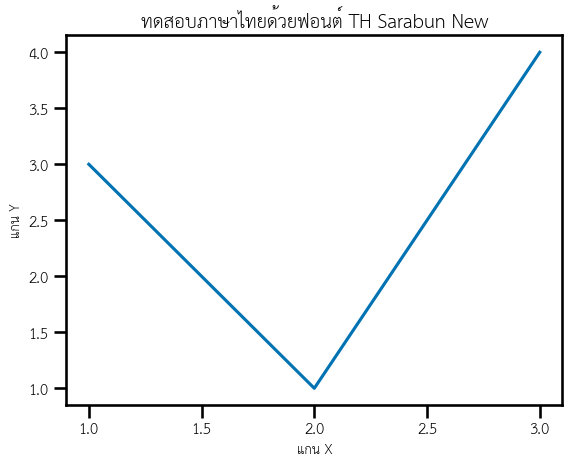

In [102]:
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams

# 🔹 ใส่พาธไปยังไฟล์ฟอนต์ของคุณ
path = r"C:\THSarabunNew.ttf"  # 👈 เปลี่ยนตามจริง
# ถ้าอยู่ในโฟลเดอร์เดียวกับไฟล์ Python ใช้แค่:
# font_path = "THSarabunNew.ttf"

# ✅ ตรวจสอบว่าไฟล์มีอยู่จริง
import os
if not os.path.exists(path):
    raise FileNotFoundError(f"❌ ไม่พบไฟล์ฟอนต์ที่ {path}")

# ✅ ลงทะเบียนฟอนต์ใน matplotlib
font_manager.fontManager.addfont(path)
rcParams["font.family"] = "TH Sarabun New"

# ✅ ทดสอบการพล็อตกราฟภาษาไทย
plt.title("ทดสอบภาษาไทยด้วยฟอนต์ TH Sarabun New", fontsize=20)
plt.plot([1, 2, 3], [3, 1, 4])
plt.xlabel("แกน X", fontsize=14)
plt.ylabel("แกน Y", fontsize=14)
plt.show()

In [103]:
import pandas as pd
import numpy as np
import re
import string
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from tensorflow.keras.utils import to_categorical
from transformers import AutoTokenizer, AutoModel
import torch

# โหลดชุดข้อมูล
df = pd.read_csv("tale_data.csv")


# 1. ฟังก์ชันทำความสะอาดข้อความตาม 3.2
def clean_text(text):
    # 1. ลบ URL
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # 2. ลบ HTML tags
    text = re.sub(r'<.*?>', '', text)
    # 3. ลบตัวเลข
    text = re.sub(r'\d+', '', text)
    # 4. ลบแฮชแท็กและ user mentions
    text = re.sub(r'[#@]\w+', '', text)
    # 5. ลบเครื่องหมายวรรคตอนและอักขระพิเศษส่วนใหญ่
    all_punct = string.punctuation + 'ฯ฿ๆๆ'
    text = text.translate(str.maketrans('', '', all_punct))
    # 6. ลบแท็บและช่องว่างส่วนเกิน
    text = ' '.join(text.split())
    return text

In [104]:

print(df.head())
print(df.shape)


   id_sentence                                             text  id_tale  Y_1  \
0  1            หนูบ้านกับหนูนา                                  1        0     
1  2            “กินอาหารกลางวันที่ต่างจังหวัด                   1        0     
2  3            น่าสนใจเป็นที่สุด!”                              1        1     
3  4            หนูบ้านอุทานเมื่อได้รับบัตรเชิญจากญาติของมัน     1       -1     
4  5            ซึ่งผู้นำข่าวนี้มาแจ้งก็คือคุณไปรษณีย์นกนั่นเอง  1        0     

   Y_2  Y_3  Y_vote  consensus  
0  0    0    0       1          
1  0    0    0       1          
2  1    1    1       1          
3  0    0    0       0          
4  0    0    0       1          
(1964, 8)


In [105]:
df.describe()
# count	จำนวนข้อมูลที่ไม่ใช่ค่าว่าง
# unique	จำนวนค่าที่ไม่ซ้ำกัน 
# top	ค่าที่ปรากฏบ่อยที่สุด 
# freq	ความถี่ของค่าที่ปรากฏบ่อยที่สุด 

,id_sentence,id_tale,Y_1,Y_2,Y_3,Y_vote,consensus
count,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000
mean,982.500000,18.440937,-0.033605,0.062118,0.062118,0.062118,0.567719
std,567.102284,12.008066,0.722882,0.759528,0.719576,0.719576,0.495519
min,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000
25%,491.750000,8.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000
50%,982.500000,17.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,1473.250000,29.000000,0.000000,1.000000,1.000000,1.000000,1.000000
max,1964.000000,40.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [106]:
# แปลง Y_vote เป็นชื่อหมวดหมู่
df['category'] = df['Y_vote'].map({
    -1: 'negative',
     0: 'neutral',
     1: 'positive'
})
df.groupby("category").describe()

id_sentence                                                       \
               count         mean         std  min    25%     50%     75%   
category                                                                    
negative  451.0       1020.059867  585.426848  7.0  468.5  987.0   1524.5   
neutral   940.0       968.279787   567.790801  1.0  488.5  960.5   1453.5   
positive  573.0       976.265271   550.770477  3.0  506.0  1020.0  1451.0   

                 id_tale             ... Y_vote      consensus            \
             max   count       mean  ...    75%  max     count      mean   
category                             ...                                   
negative  1963.0  451.0   19.266075  ... -1.0   -1.0  451.0     0.660754   
neutral   1958.0  940.0   18.164894  ...  0.0    0.0  940.0     0.540426   
positive  1964.0  573.0   18.244328  ...  1.0    1.0  573.0     0.539267   

                                             
               std  min  25%  50%  75%  max  
category                                     
negative  0.473979  0.0  0.0  1.0  1.0  1.0  
neutral   0.498628  0.0  0.0  1.0  1.0  1.0  
positive  0.498891  0.0  0.0  1.0  1.0  1.0  

[3 rows x 56 columns]

In [107]:
import pandas as pd

# 🔹 โหลดไฟล์ CSV เดิม
data_df = pd.read_csv("tale_data.csv")

# 🔹 ตรวจสอบชื่อคอลัมน์ก่อน
print("📋 ชื่อคอลัมน์:", data_df.columns)

# 🔹 สมมติว่าคอลัมน์ข้อความชื่อว่า "text" และคอลัมน์ป้ายกำกับคือ "Y_vote"
# (ถ้าไม่ตรงชื่อจริง ให้แก้ในบรรทัดนี้)
texts = data_df["text"].astype(str).tolist()
labels = data_df["Y_vote"].astype(str).tolist()

# 🔹 รวมเป็น DataFrame ที่ใช้เทรนโมเดลได้
df = pd.DataFrame({
    "category": labels,
    "texts": texts
})

# 🔹 บันทึกเป็น _train.csv
df.to_csv("_train1.csv", index=False, encoding="utf-8-sig")

print("✅ แปลงสำเร็จ:", df.shape)
print(df.head())


📋 ชื่อคอลัมน์: Index(['id_sentence', 'text', 'id_tale', 'Y_1', 'Y_2', 'Y_3', 'Y_vote',
       'consensus'],
      dtype='object')
✅ แปลงสำเร็จ: (1964, 2)
  category                                            texts
0  0        หนูบ้านกับหนูนา                                
1  0        “กินอาหารกลางวันที่ต่างจังหวัด                 
2  1        น่าสนใจเป็นที่สุด!”                            
3  0        หนูบ้านอุทานเมื่อได้รับบัตรเชิญจากญาติของมัน   
4  0        ซึ่งผู้นำข่าวนี้มาแจ้งก็คือคุณไปรษณีย์นกนั่นเอง


In [108]:
import pandas as pd

# 🔹 โหลดข้อมูลจากไฟล์ CSV เดิม
data_df = pd.read_csv("tale_data.csv")

# 🔹 ตรวจสอบชื่อคอลัมน์
print("📋 คอลัมน์ที่มี:", data_df.columns.tolist())

# 🔹 ใช้คอลัมน์ 'text' แทน 'texts'
texts = data_df["text"].astype(str).tolist()  
labels = ["neu"] * len(texts)  # ให้ทุกบรรทัดเป็น class = neu

# 🔹 สร้าง DataFrame ใหม่
test_df = pd.DataFrame({
    "category": labels,
    "texts": texts
})

# 🔹 บันทึกเป็นไฟล์ CSV ใหม่
test_df.to_csv("_test1.csv", index=False, encoding="utf-8-sig")

print("✅ สร้างไฟล์ _test.csv สำเร็จ ขนาด:", test_df.shape)
print(test_df.head())


📋 คอลัมน์ที่มี: ['id_sentence', 'text', 'id_tale', 'Y_1', 'Y_2', 'Y_3', 'Y_vote', 'consensus']
✅ สร้างไฟล์ _test.csv สำเร็จ ขนาด: (1964, 2)
  category                                            texts
0  neu      หนูบ้านกับหนูนา                                
1  neu      “กินอาหารกลางวันที่ต่างจังหวัด                 
2  neu      น่าสนใจเป็นที่สุด!”                            
3  neu      หนูบ้านอุทานเมื่อได้รับบัตรเชิญจากญาติของมัน   
4  neu      ซึ่งผู้นำข่าวนี้มาแจ้งก็คือคุณไปรษณีย์นกนั่นเอง


In [109]:
df.describe()
# count	จำนวนข้อมูลที่ไม่ใช่ค่าว่าง
# unique	จำนวนค่าที่ไม่ซ้ำกัน 
# top	ค่าที่ปรากฏบ่อยที่สุด 
# freq	ความถี่ของค่าที่ปรากฏบ่อยที่สุด 

,category,texts
count,1964,1964
unique,3,1950
top,0,อีแรน เดอเกลแปร์
freq,940,8


In [110]:
df.groupby("category").describe()
# neg	Negativeเชิงลบ 
# neu	Neutralเป็นกลาง 
# pos	Positiveเชิงบวก 
# q	Questionคำถาม 

texts         \
         count unique   
category                
-1        451   451     
0         940   927     
1         573   572     

                                                                                                                       \
                                                                                                                  top   
category                                                                                                                
-1        หนูน้อยยังคงฝันเฟื่องต่อไป ขณะที่มองออกไปนอกหน้าต่างแล้วเห็นความวุ่นวายตรงถนนข้างล่าง                         
0         อีแรน เดอเกลแปร์                                                                                              
1         “โอ เทพซีอุสผู้ยิ่งใหญ่ พวกเราไซร้พร้อมกันร้องสรรเสริญ ขอท่านโปรดเมตตาพวกเราเทอญ จงอัญเชิญพระราชามาให้เรา!”   

               
         freq  
category       
-1        1    
0         8    
1         2

In [111]:
#ตรวจนับจำนวนคำในแต่ละข้อความครับ
df["length"] = df["texts"].apply(word_tokenize).apply(len)
df.head()

,category,texts,length
0,0,หนูบ้านกับหนูนา,5
1,0,“กินอาหารกลางวันที่ต่างจังหวัด,5
2,1,น่าสนใจเป็นที่สุด!”,4
3,0,หนูบ้านอุทานเมื่อได้รับบัตรเชิญจากญาติของมัน,10
4,0,ซึ่งผู้นำข่าวนี้มาแจ้งก็คือคุณไปรษณีย์นกนั่นเอง,12


<Axes: >

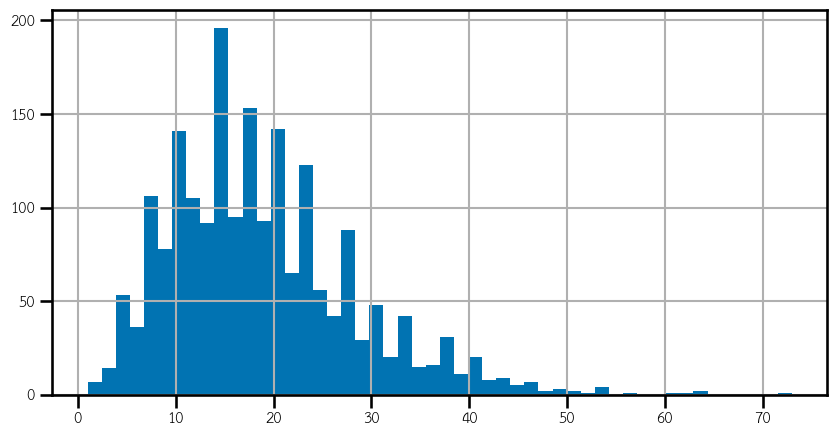

In [112]:
#วิเคราะห์ความยาวข้อความใน DataFrame ด้วยการสร้าง Histogram ครับ
df["length"].hist(bins=50, figsize=(10, 5))

In [113]:
import pandas as pd

# คำนวณสถิติ
desc = df['length'].describe()

# สร้างตารางพร้อมคำอธิบาย
table_data = [
    ["count", int(desc['count']), "จำนวนแถวทั้งหมดที่มีข้อมูลในคอลัมน์นี้"],
    ["mean", round(desc['mean'], 2), "ค่าเฉลี่ยของจำนวนคำต่อข้อความ"],
    ["std", round(desc['std'], 2), "ส่วนเบี่ยงเบนมาตรฐานของความยาวข้อความ"],
    ["min", int(desc['min']), "ข้อความที่สั้นที่สุด"],
    ["25%", int(desc['25%']), "25% ของข้อความมีความยาว ≤ ค่านี้ (ควอร์ไทล์ล่าง)"],
    ["50%", int(desc['50%']), "Median ของความยาวข้อความ (ค่ากลาง)"],
    ["75%", int(desc['75%']), "75% ของข้อความมีความยาว ≤ ค่านี้ (ควอร์ไทล์บน)"],
    ["max", int(desc['max']), "ข้อความที่ยาวที่สุด"]
]

# สร้าง DataFrame
summary_table = pd.DataFrame(table_data, columns=["ค่าที่ได้", "ค่า", "ความหมาย"])

# แสดงตาราง
summary_table


,ค่าที่ได้,ค่า,ความหมาย
0,count,1964.00,จำนวนแถวทั้งหมดที่มีข้อมูลในคอลัมน์นี้
1,mean,18.85,ค่าเฉลี่ยของจำนวนคำต่อข้อความ
2,std,9.55,ส่วนเบี่ยงเบนมาตรฐานของความยาวข้อความ
3,min,1.00,ข้อความที่สั้นที่สุด
4,25%,12.00,25% ของข้อความมีความยาว ≤ ค่านี้ (ควอร์ไทล์ล่าง)
5,50%,17.00,Median ของความยาวข้อความ (ค่ากลาง)
6,75%,24.00,75% ของข้อความมีความยาว ≤ ค่านี้ (ควอร์ไทล์บน)
7,max,73.00,ข้อความที่ยาวที่สุด


In [114]:
df[df["length"] >= 73]

,category,texts,length
615,1,หลังจากกินอาหารกันอย่างเอร็ดอร่อยแล้วทุกคนก็ช่วยกันทำงานต่อ พวกช่างเริ่มลงมือสร้างส่วนปีกติดให้ห้องสมุด โดยมีวิศวกรกับหนังสือคู่ใจช่วยออกแบบและควบคุมดูแลการสร้าง นักวิทยาศาสตร์กับช่างเครื่องยนต์ได้ช่วยกันติดตั้งเครื่องยนต์ โดยมีหนังสือตำราร่วมให้คำปรึกษา ส่วนนักบินกำลังออกแบบระบบควบคุมการบินให้คุณยายสามารถบังคับได้อย่างสบายด้วยปุ่มเพียงปุ่มเดียว,73


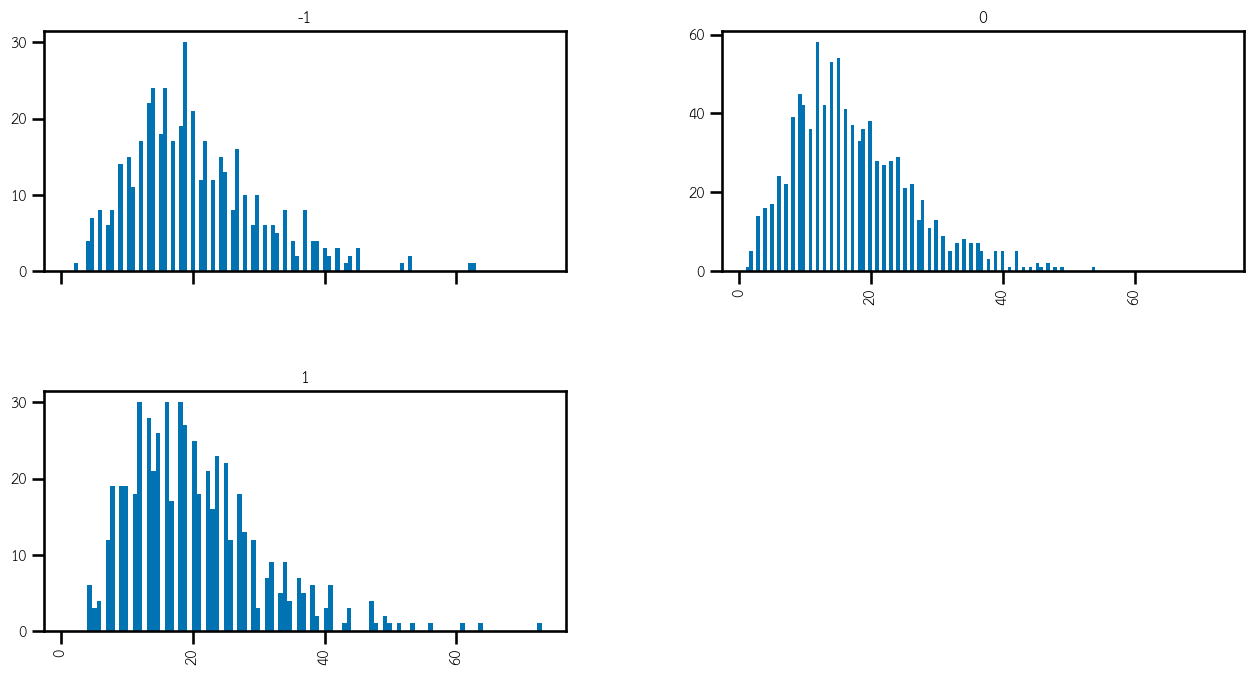

In [115]:
df.hist(column="length", by="category", bins=100, figsize=(15,8), sharex=True)
plt.show()

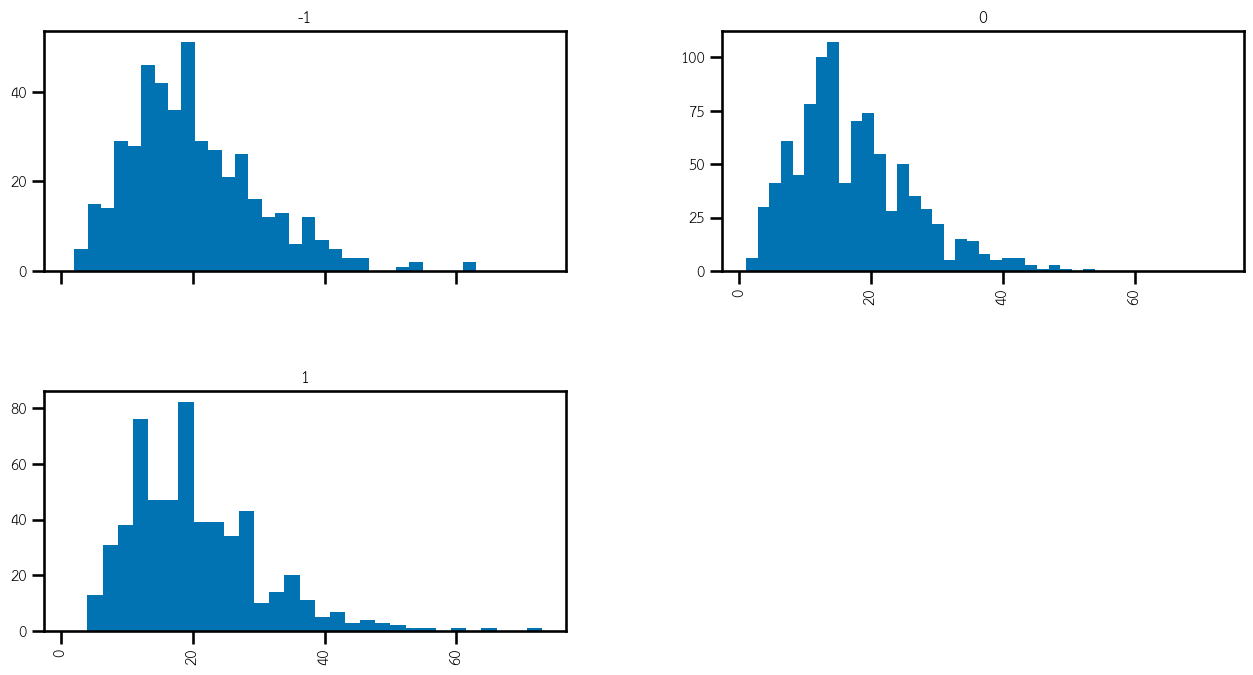

In [116]:
df[df["length"] <= 100].hist(column="length", by="category", bins=30, figsize=(15,8), sharex=True)
plt.show()

In [132]:
#เลือกตัวอย่างข้อมูลความเป็นกลาง
neu_df = df[df.category == "0"]
neu_df.head()

,category,texts,length
0,0,หนูบ้านกับหนูนา,5
1,0,“กินอาหารกลางวันที่ต่างจังหวัด,5
3,0,หนูบ้านอุทานเมื่อได้รับบัตรเชิญจากญาติของมัน,10
4,0,ซึ่งผู้นำข่าวนี้มาแจ้งก็คือคุณไปรษณีย์นกนั่นเอง,12
8,0,“ขอโทษนะจ๊ะ” นกไปรษณีย์พูด,8


In [24]:
#แยกเฉพาะข้อมูลที่มีความรู้สึกเป็นเชิงบวก (Positive Sentiment) ออกจาก DataFrame หลัก
pos_df = df[df.category == "1"]
pos_df.head()


,category,texts,length
2,1,น่าสนใจเป็นที่สุด!”,4
5,1,“อากาศสดชื่น แสงแดดอ่อนๆ มีแต่ความเงียบและสงบสุข...”,15
7,1,“เชื่อเลยว่าอาหารต้องมีรสชาติวิเศษสุด เวลาที่เราพักผ่อนอยู่ในสวนดอกไม้ใต้ท้องฟ้ากว้าง”,22
10,1,“ต้องตอบจดหมายไหม” “โอ จริงสินะ” หนูบ้านพูด,18
11,1,“ช่วยบอกเขาด้วยว่าฉันยินดีที่จะไป ฉันจะไปถึงที่นั่นตอนเที่ยงวันพรุ่งนี้”,18


In [25]:
neg_df = df[df.category == "-1"]
neg_df.head()

,category,texts,length
6,-1,หนูน้อยยังคงฝันเฟื่องต่อไป ขณะที่มองออกไปนอกหน้าต่างแล้วเห็นความวุ่นวายตรงถนนข้างล่าง,16
9,-1,มันกำลังคอยอยู่ที่ขอบหน้าต่างอย่างร้อนใจ,9
20,-1,เจ้าหนูไต่ขึ้นไปยังที่ว่างข้างหน้าต่าง มันมองภาพเมืองอันวุ่นวายที่วิ่งผ่านไป บ้านและร้านรวง ตรอกซอยและถนน ผู้คนและเสาไฟ รถประจำทางและรถยนต์ขับผ่านไปอย่างรวดเร็ว,42
21,-1,ภาพเหล่านั้นค่อยๆ เปิดทางให้เนินเขาสีเขียวสูงๆ ต่ำๆ ลดหลั่นกัน และทุ่งดอกไม้กว้างสุดตาเผยออกมา กระทั่งรถไฟมาหยุดที่สถานีชนบทที่เงียบเหงาแห่งหนึ่ง,38
22,-1,เจ้าหนูจึงกระโดดลง มันกระโดดลงไปตามขั้นบันไดที่สถานีแล้วมายืนอยู่บนถนนนอกเมืองสายเล็กๆ ที่แสนเงียบเหงา,28


In [26]:
sentiment_df = pd.concat([neg_df, pos_df, neu_df])
sentiment_df = sentiment_df.reset_index(drop=True)
sentiment_df.groupby("category").texts.describe()

,count,unique,top,freq
category,,,,
-1,451,451,หนูน้อยยังคงฝันเฟื่องต่อไป ขณะที่มองออกไปนอกหน้าต่างแล้วเห็นความวุ่นวายตรงถนนข้างล่าง,1
0,940,927,อีแรน เดอเกลแปร์,8
1,573,572,“โอ เทพซีอุสผู้ยิ่งใหญ่ พวกเราไซร้พร้อมกันร้องสรรเสริญ ขอท่านโปรดเมตตาพวกเราเทอญ จงอัญเชิญพระราชามาให้เรา!”,2


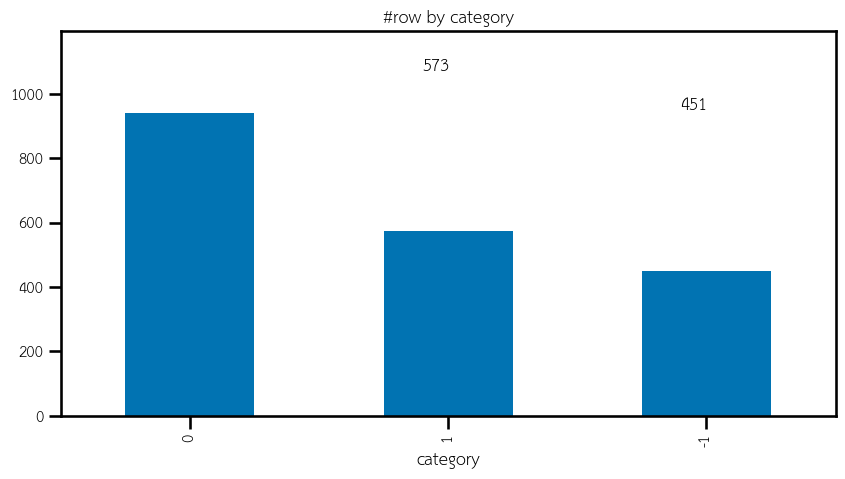

In [27]:
#นับจำนวนข้อมูลในแต่ละประเภท
row_count_by_category = sentiment_df.category.value_counts()

ax = row_count_by_category.plot(
    kind="bar",                      # ✅ ใช้ keyword argument
    title="#row by category",
    figsize=(10, 5)
)

ax.set_ylim(0, row_count_by_category.max() + row_count_by_category.std())

# 🔹 แสดงค่าบนแท่ง
for i, label in enumerate(row_count_by_category):
    ax.annotate(str(label), (i - 0.1, label + 500))

plt.show()


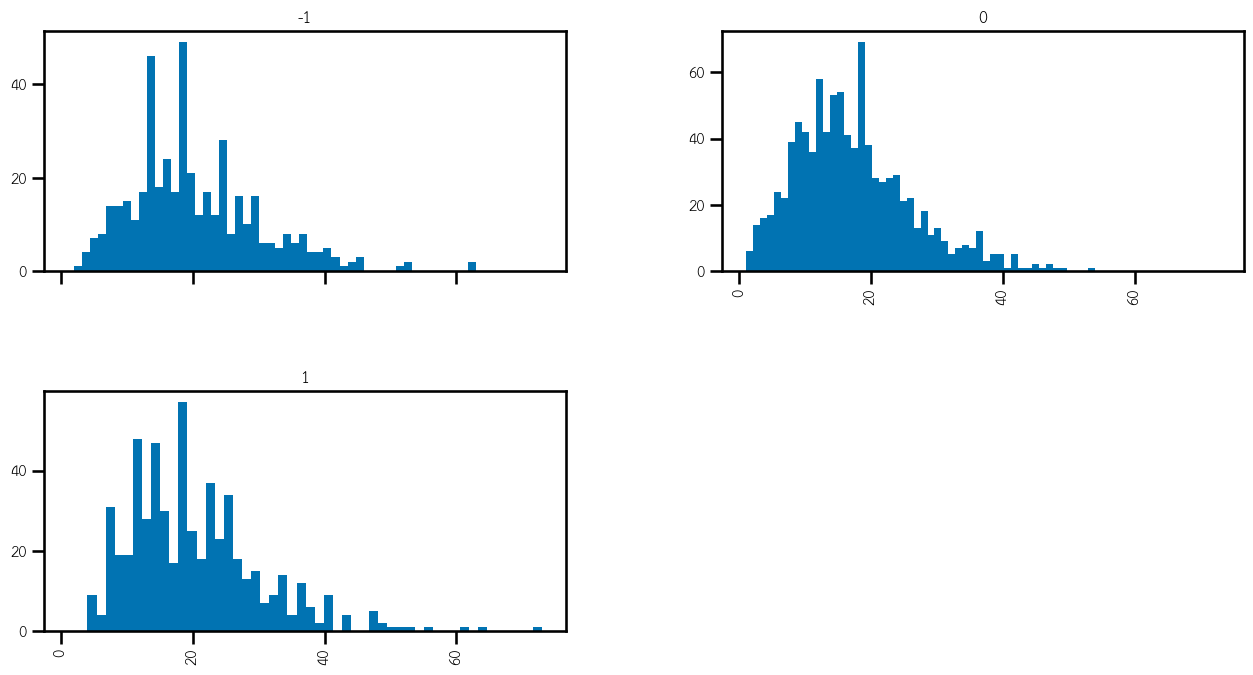

In [28]:
sentiment_df.hist(column="length", by="category", bins=50, figsize=(15, 8), sharex=True)
plt.show()

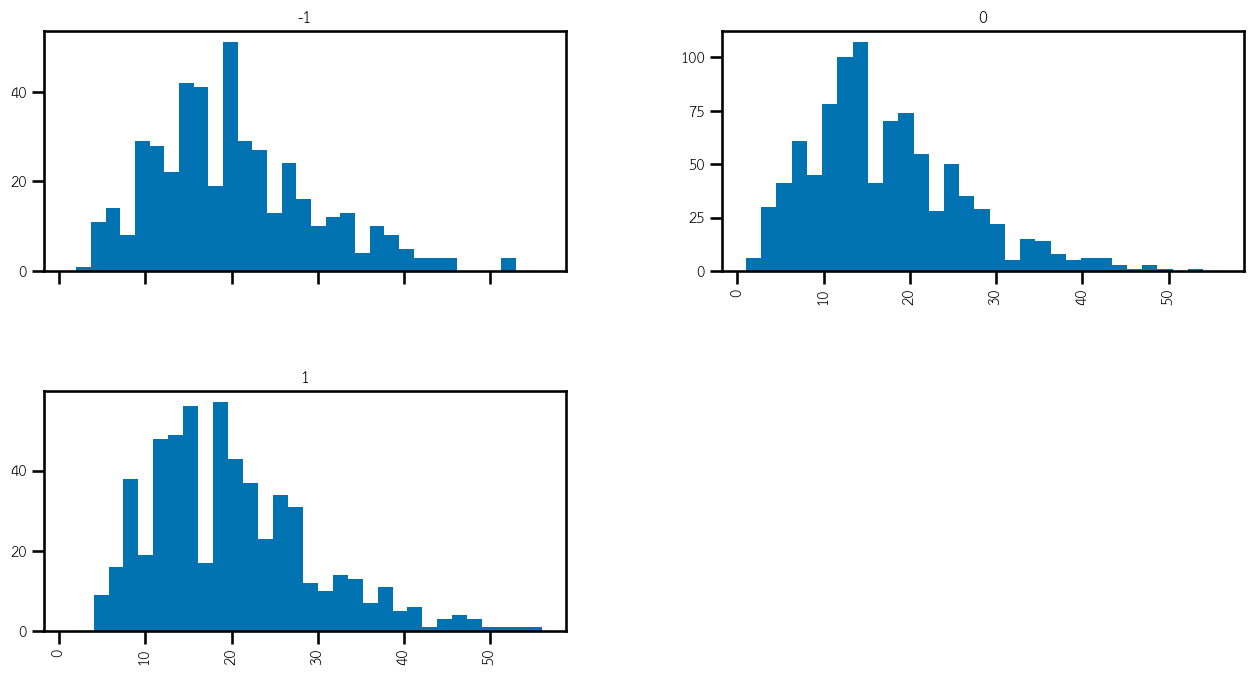

In [29]:
sentiment_df[sentiment_df.length < 60].hist(column="length", by="category", bins=30, figsize=(15, 8), sharex=True)
plt.show()

In [30]:
class_names = np.unique(sentiment_df.category).tolist()

In [86]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(sentiment_df["texts"], sentiment_df["category"], test_size=0.20, random_state=42)

In [135]:
import numpy as np  # สำหรับจัดการตัวเลขและอาเรย์
from sklearn.preprocessing import LabelEncoder  # สำหรับแปลง label เป็นตัวเลข
from tensorflow.keras.preprocessing.text import Tokenizer  # สำหรับแปลงข้อความเป็น sequence ของตัวเลข
from tensorflow.keras.preprocessing.sequence import pad_sequences  # สำหรับปรับความยาว sequence
from tensorflow.keras.utils import to_categorical  # สำหรับแปลง label เป็น one-hot encoding
from tensorflow.keras.models import Sequential  # สำหรับสร้างโมเดลแบบ Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, LSTM, Bidirectional, Dense, Dropout  # นำเข้า layer ต่าง ๆ

# =========================
# 🔹 แปลง labels เป็นตัวเลขและ one-hot
# =========================
le = LabelEncoder()  # สร้าง LabelEncoder
y = le.fit_transform(sentiment_df['category'])  # แปลง category เป็นตัวเลข
y_cat = to_categorical(y)  # แปลงเป็น one-hot encoding

# =========================
# 🔹 แบ่งข้อมูล train/test
# =========================
from sklearn.model_selection import train_test_split  # นำเข้า train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    sentiment_df['texts'], y_cat, test_size=0.2, random_state=42
)
# test_size=0.2 แปลว่า 20% ของข้อมูลเป็น test set
# random_state=42 เพื่อให้ผลลัพธ์ซ้ำได้

# =========================
# 🔹 Tokenize ข้อความ
# =========================
max_words = 10000  # จำนวนคำสูงสุดใน vocabulary
max_len = 194      # ความยาว sequence สูงสุด
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")  # สร้าง tokenizer พร้อม OOV token
tokenizer.fit_on_texts(X_train)  # สร้าง dictionary ของคำจาก train data

X_train_seq = tokenizer.texts_to_sequences(X_train)  # แปลงข้อความ train เป็น sequence ของตัวเลข
X_test_seq = tokenizer.texts_to_sequences(X_test)    # แปลงข้อความ test เป็น sequence ของตัวเลข

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')  # เติม 0 ด้านท้าย
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')    # เติม 0 ด้านท้าย

# =========================
# 🔹 สร้างโมเดล CNN-BiLSTM
# =========================
model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    # 🔹 Embedding layer แปลงเลขคำเป็น vector ขนาด 128

    Conv1D(128, kernel_size=3, activation='relu', padding='same'),
    # 🔹 Conv1D kernel size 3, filter 128, activation ReLU
    MaxPooling1D(pool_size=2),
    # 🔹 MaxPooling ลดความยาว sequence ลงครึ่งหนึ่ง

    Conv1D(128, kernel_size=5, activation='relu', padding='same'),
    # 🔹 Conv1D kernel size 5, filter 128, activation ReLU
    MaxPooling1D(pool_size=2),
    # 🔹 MaxPooling ลดความยาว sequence อีกครั้ง

    Bidirectional(LSTM(64, return_sequences=False)),
    # 🔹 BiLSTM 64 units, return_sequences=False เพื่อ output vector เดียว

    Dropout(0.6),
    # 🔹 Dropout 60% เพื่อลด overfitting

    Dense(y_cat.shape[1], activation='softmax')
    # 🔹 Dense layer output = จำนวน class, activation softmax
])

# =========================
# 🔹 Compile โมเดล
# =========================
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=0.00001)  # learning rate เล็กมาก 0.00001
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
# loss=categorical_crossentropy สำหรับ multi-class classification
# metrics=['accuracy'] เพื่อติดตามค่า accuracy

model.summary()  # แสดงสรุปโครงสร้างโมเดล

# =========================
# 🔹 Train โมเดล
# =========================
history = model.fit(
    X_train_pad, y_train_cat,  # ข้อมูล train
    validation_data=(X_test_pad, y_test_cat),  # ข้อมูล validation
    epochs=100,               # จำนวน epoch 100 รอบ
    batch_size=64,            # batch size 64
    verbose=1                 # แสดง progress bar
)


C:\Program Files\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_39 (Embedding)             │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_72 (Conv1D)                   │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_72 (MaxPooling1D)      │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_73 (Conv1D)                   │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_73 (MaxPooling1D)      │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_38 (Bidirectional)     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_38 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_36 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.3173 - loss: 1.1029 - val_accuracy: 0.3003 - val_loss: 1.0960
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.3661 - loss: 1.0944 - val_accuracy: 0.4555 - val_loss: 1.0907
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.4381 - loss: 1.0870 - val_accuracy: 0.4555 - val_loss: 1.0853
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.4605 - loss: 1.0822 - val_accuracy: 0.4555 - val_loss: 1.0806
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.4788 - loss: 1.0743 - val_accuracy: 0.4555 - val_loss: 1.0763
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.4853 - loss: 1.0673 - val_accuracy: 0.4555 - val_loss: 1.0728
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.4947 - loss: 1.0630 - val_accuracy: 0.4555 - val_loss: 1.0697
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.4657 - loss: 1.0668 - val_accuracy: 0.

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


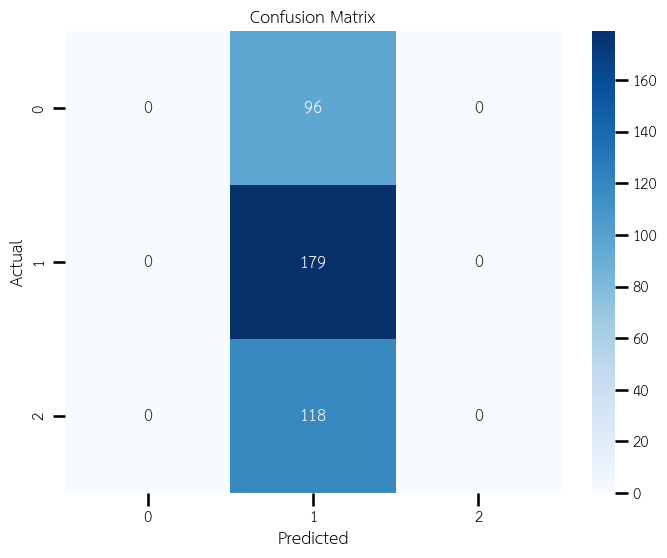

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00        96
           0       0.46      1.00      0.63       179
           1       0.00      0.00      0.00       118

    accuracy                           0.46       393
   macro avg       0.15      0.33      0.21       393
weighted avg       0.21      0.46      0.29       393



C:\Program Files\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Program Files\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Program Files\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [127]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ทำนายผล
y_pred_prob = model.predict(X_test_pad)

# แปลงเป็น label ตัวเลข
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification Report (Precision, Recall, F1)
report = classification_report(y_true, y_pred, target_names=le.classes_)
print(report)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, LSTM, Bidirectional, Dense, Dropout, GlobalMaxPooling1D
# นำเข้า Layer และ Model สำหรับสร้าง BiLSTM-CNN

# =========================
# 🔹 พารามิเตอร์
# =========================
max_words = 10000  # จำนวนคำสูงสุดใน vocabulary
max_len = 194      # ความยาว sequence สูงสุด

# =========================
# 🔹 สร้างโมเดล BiLSTM-CNN
# =========================
bilstm_cnn_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    # 🔹 Embedding layer แปลง word index เป็น vector ขนาด 128

    Bidirectional(LSTM(64, return_sequences=True)),
    # 🔹 BiLSTM 64 units, return_sequences=True เพื่อให้ output เป็น sequence (ต่อ Conv1D ใช้)

    Conv1D(32, kernel_size=3, activation='relu', padding='same'),
    # 🔹 Conv1D kernel size 3, filter 32, activation ReLU
    MaxPooling1D(pool_size=2),
    # 🔹 MaxPooling ลดความยาว sequence ครึ่งหนึ่ง

    Conv1D(32, kernel_size=5, activation='relu', padding='same'),
    # 🔹 Conv1D kernel size 5, filter 32, activation ReLU
    MaxPooling1D(pool_size=2),
    # 🔹 MaxPooling ลดความยาว sequence ครึ่งหนึ่งอีกครั้ง

    GlobalMaxPooling1D(),
    # 🔹 GlobalMaxPooling แปลง sequence เป็น vector เดียว

    Dropout(0.6),
    # 🔹 Dropout 60% เพื่อลด overfitting

    Dense(y_cat.shape[1], activation='softmax')
    # 🔹 Dense layer output = จำนวน class, activation softmax
])

# =========================
# 🔹 Compile โมเดล
# =========================
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=0.00001)  # learning rate เล็กมาก 0.00001
bilstm_cnn_model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
# loss=categorical_crossentropy สำหรับ multi-class classification
# metrics=['accuracy'] เพื่อติดตามค่า accuracy

bilstm_cnn_model.summary()  # แสดง summary ของโมเดล

# =========================
# 🔹 Train โมเดล
# =========================
history_bilstm_cnn = bilstm_cnn_model.fit(
    X_train_pad, y_train,                # ข้อมูล train
    validation_data=(X_test_pad, y_test),# ข้อมูล validation
    epochs=100,                          # จำนวน epoch 100 รอบ
    batch_size=64                        # batch size 64
)

# =========================
# 🔹 ประเมินผล F1-score และ Confusion Matrix
# =========================
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 🔹 ทำนายผล test set
y_pred_prob = bilstm_cnn_model.predict(X_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)  # แปลง probability เป็น class index
y_true = np.argmax(y_test, axis=1)        # แปลง one-hot test label เป็น class index

# 🔹 Classification Report (Precision, Recall, F1-score)
print(classification_report(y_true, y_pred, target_names=le.classes_))

# 🔹 Confusion Matrix
conf_mat = confusion_matrix(y_true, y_pred)  # สร้าง confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(conf_mat, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')  # แกน x = predicted label
plt.ylabel('Actual')     # แกน y = actual label
plt.title("BiLSTM-CNN Confusion Matrix")
plt.show()  # แสดง heatmap ของ co


In [130]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Conv1D, MaxPooling1D, LSTM, Bidirectional, Dense, Dropout, GlobalMaxPooling1D, Concatenate
from tensorflow.keras.optimizers import Adam

# =========================
# 🔹 Parallel Hybrid Model
# =========================

# พารามิเตอร์
max_words = 10000       # จำนวนคำสูงสุดใน vocabulary
max_len = 194           # ความยาว sequence สูงสุด
embedding_dim = 128     # ขนาด embedding vector
learning_rate = 0.00001 # learning rate เล็กมาก
batch_size = 64         # batch size
epochs_parallel = 100   # จำนวน epoch

# =========================
# 🔹 Input & Embedding
# =========================
input_layer = Input(shape=(max_len,))
# สร้าง Input layer shape = (max_len,)
embedding_layer = Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len)(input_layer)
# แปลงเลขคำเป็น embedding vector ขนาด embedding_dim

# =========================
# 🔹 BiLSTM branch
# =========================
bilstm_branch = Bidirectional(LSTM(64, return_sequences=True))(embedding_layer)
# BiLSTM 64 units, return_sequences=True เพื่อ output เป็น sequence
bilstm_branch = GlobalMaxPooling1D()(bilstm_branch)
# GlobalMaxPooling แปลง sequence เป็น vector เดียว

# =========================
# 🔹 CNN branch
# =========================
conv_branch = Conv1D(32, kernel_size=3, activation='relu', padding='same')(embedding_layer)
# Conv1D kernel size=3, filter=32, activation ReLU
conv_branch = MaxPooling1D(pool_size=2)(conv_branch)
# MaxPooling ลดความยาว sequence ครึ่งหนึ่ง
conv_branch = Conv1D(32, kernel_size=5, activation='relu', padding='same')(conv_branch)
# Conv1D kernel size=5, filter=32, activation ReLU
conv_branch = MaxPooling1D(pool_size=2)(conv_branch)
# MaxPooling ลดความยาว sequence ครึ่งหนึ่งอีกครั้ง
conv_branch = GlobalMaxPooling1D()(conv_branch)
# GlobalMaxPooling แปลง sequence เป็น vector เดียว

# =========================
# 🔹 รวมสอง branch
# =========================
merged = Concatenate()([bilstm_branch, conv_branch])
# รวม vector จาก BiLSTM branch และ CNN branch
dropout = Dropout(0.6)(merged)
# Dropout 60% เพื่อลด overfitting
output = Dense(y_cat.shape[1], activation='softmax')(dropout)
# Dense layer output = จำนวน class, activation softmax

# =========================
# 🔹 สร้างและ compile โมเดล
# =========================
parallel_model = Model(inputs=input_layer, outputs=output)
parallel_model.compile(
    loss='categorical_crossentropy',           # loss สำหรับ multi-class classification
    optimizer=Adam(learning_rate=learning_rate),
    metrics=['accuracy']
)

parallel_model.summary()  # แสดง summary ของโมเดล

# =========================
# 🔹 Train โมเดล
# =========================
history_parallel = parallel_model.fit(
    X_train_pad, y_train,                  # ข้อมูล train
    validation_data=(X_test_pad, y_test),  # ข้อมูล validation
    epochs=epochs_parallel,                # จำนวน epoch
    batch_size=batch_size                  # batch size
)


C:\Program Files\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_34 (InputLayer)   │ (None, 194)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_38 (Embedding)      │ (None, 194, 128)          │       1,280,000 │ input_layer_34[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_70 (Conv1D)            │ (None, 194, 32)           │          12,320 │ embedding_38[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling1d_70              │ (None, 97, 32)            │               0 │ conv1d_70[0][0]            │
│ (MaxPooling1D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_71 (Conv1D)            │ (None, 97, 32)            │           5,152 │ max_pooling1d_70[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bidirectional_37              │ (None, 194, 128)          │          98,816 │ embedding_38[0][0]         │
│ (Bidirectional)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling1d_71              │ (None, 48, 32)            │               0 │ conv1d_71[0][0]            │
│ (MaxPooling1D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_max_pooling1d_4        │ (None, 128)               │               0 │ bidirectional_37[0][0]     │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_max_pooling1d_5        │ (None, 32)                │               0 │ max_pooling1d_71[0][0]     │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_8 (Concatenate)   │ (None, 160)               │               0 │ global_max_pooling1d_4[0]… │
│                               │                           │                 │ global_max_pooling1d_5[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_37 (Dropout)          │ (None, 160)               │               0 │ concatenate_8[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_35 (Dense)              │ (None, 3)                 │             483 │ dropout_37[0][0]           │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 1,396,771 (5.33 MB)

 Trainable params: 1,396,771 (5.33 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.3569 - loss: 1.0962 - val_accuracy: 0.4555 - val_loss: 1.0931
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.4035 - loss: 1.0919 - val_accuracy: 0.4555 - val_loss: 1.0909
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.4566 - loss: 1.0883 - val_accuracy: 0.4555 - val_loss: 1.0888
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.4433 - loss: 1.0875 - val_accuracy: 0.4555 - val_loss: 1.0868
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.4819 - loss: 1.0837 - val_accuracy: 0.4555 - val_loss: 1.0849
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.4765 - loss: 1.0814 - val_accuracy: 0.4555 - val_loss: 1.0830
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.4934 - loss: 1.0760 - val_accuracy: 0.4555 - val_loss: 1.0813
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.4488 - loss: 1.0804 - val_accuracy: 0.

C:\Program Files\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Program Files\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Program Files\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


NameError: name 'f1_score' is not defined

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
=== Parallel Hybrid Classification Report ===
              precision    recall  f1-score   support

          -1       0.00      0.00      0.00        96
           0       0.46      1.00      0.63       179
           1       0.00      0.00      0.00       118

    accuracy                           0.46       393
   macro avg       0.15      0.33      0.21       393
weighted avg       0.21      0.46      0.29       393

F1-score (macro): 0.2086
F1-score (micro): 0.4555
F1-score (weighted): 0.2851


C:\Program Files\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Program Files\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Program Files\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


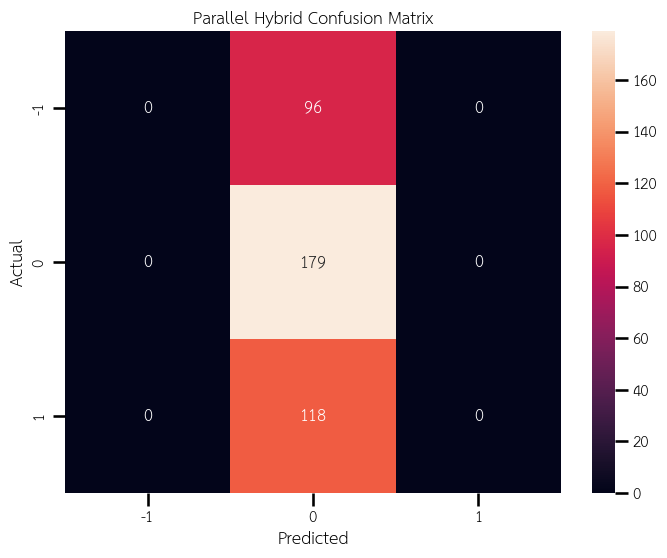

In [131]:
# =======================
# ประเมิน Parallel Hybrid
# =======================
from sklearn.metrics import classification_report, confusion_matrix, f1_score
y_pred_prob_parallel = parallel_model.predict(X_test_pad)
y_pred_parallel = np.argmax(y_pred_prob_parallel, axis=1)
y_true = np.argmax(y_test, axis=1)

# Classification report
print("=== Parallel Hybrid Classification Report ===")
print(classification_report(y_true, y_pred_parallel, target_names=le.classes_))

# F1-score macro/micro/weighted
f1_macro = f1_score(y_true, y_pred_parallel, average='macro')
f1_micro = f1_score(y_true, y_pred_parallel, average='micro')
f1_weighted = f1_score(y_true, y_pred_parallel, average='weighted')
print(f"F1-score (macro): {f1_macro:.4f}")
print(f"F1-score (micro): {f1_micro:.4f}")
print(f"F1-score (weighted): {f1_weighted:.4f}")

# Confusion Matrix
conf_mat_parallel = confusion_matrix(y_true, y_pred_parallel)
plt.figure(figsize=(8,6))
sns.heatmap(conf_mat_parallel, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Parallel Hybrid Confusion Matrix")
plt.show()